

> Dataset base model training



In [ ]:
##Necessary Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
##Load data & Process Data

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
data = pd.read_csv('https://drive.google.com/uc?export=download&id=1Vnkk3KNrexqh5_bKa_5VXLo1dPcWR29k')
print(data.head(3))

# Drop ID column
data.drop("id", axis=1, inplace=True)

# Encode target variable
data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

# Split features and target
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38           122.8     1001.0   
1    842517         M        20.57         17.77           132.9     1326.0   
2  84300903         M        19.69         21.25           130.0     1203.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   

   ...  radius_worst  texture_worst  perimeter_worst  area_worst  \
0  ...         25.38          17.33            184.6      2019.0   
1  ...         24.99          23.41            158.8      1956.0   
2  ...         23.57          25.53      

In [ ]:
##Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
##Train Data
# ---- SVM (BEST MODEL) ----
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

# ---- Logistic Regression ----
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# ---- Random Forest ----
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# ---- Gradient Boosting ----
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# ---- KNN ----
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)


In [ ]:
##Evaluation
models = {
    "SVM": svm_pred,
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "KNN": knn_pred
}

print("\nMODEL ACCURACY COMPARISON\n")

for name, preds in models.items():
    print(f"{name} Accuracy: {accuracy_score(y_test, preds):.4f}")


print("\nBEST MODEL: SVM (RBF Kernel)")
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("\nClassification Report:\n", classification_report(y_test, svm_pred))

print("\nBEST MODEL: Logistic Regression")
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

print("\nBEST MODEL: Random Forest")
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

print("\nBEST MODEL: Gradient Boosting")
print("Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("\nClassification Report:\n", classification_report(y_test, gb_pred))

print("\nBEST MODEL: KNN")
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))


MODEL ACCURACY COMPARISON

SVM Accuracy: 0.9737
Logistic Regression Accuracy: 0.9649
Random Forest Accuracy: 0.9649
Gradient Boosting Accuracy: 0.9649
KNN Accuracy: 0.9561

BEST MODEL: SVM (RBF Kernel)
Confusion Matrix:
 [[72  0]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


BEST MODEL: Logistic Regression
Confusion Matrix:
 [[71  1]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      

/tmp/ipython-input-963258408.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="viridis")


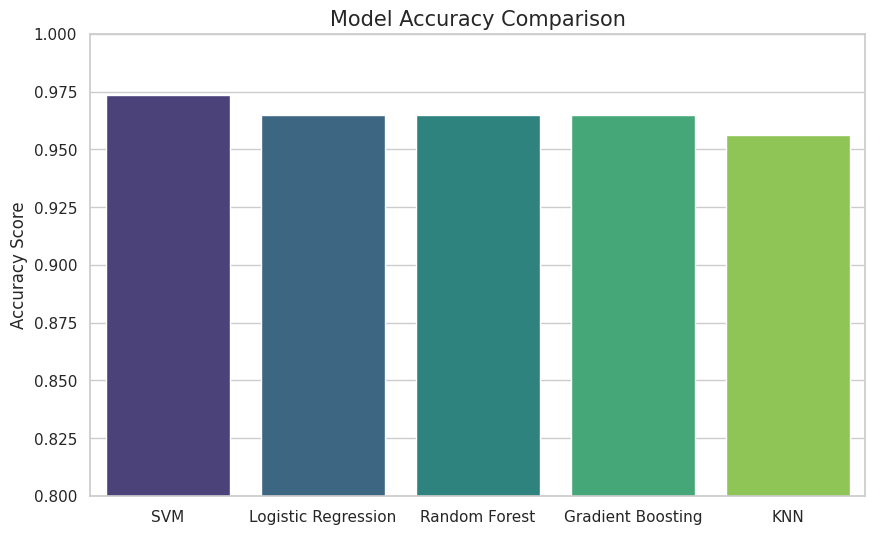

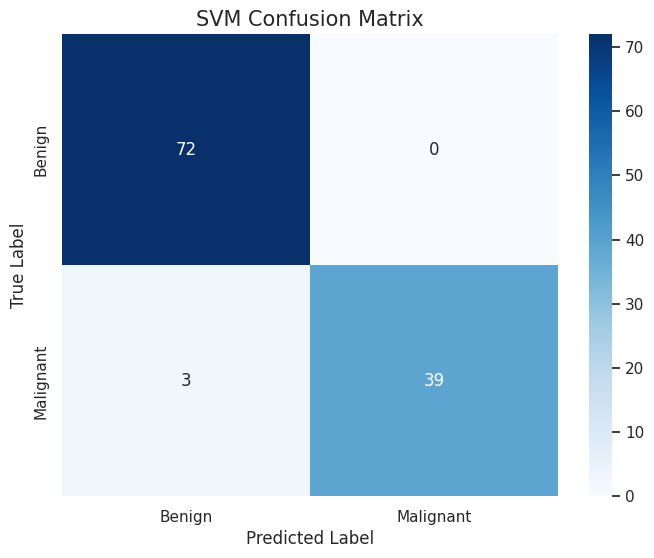

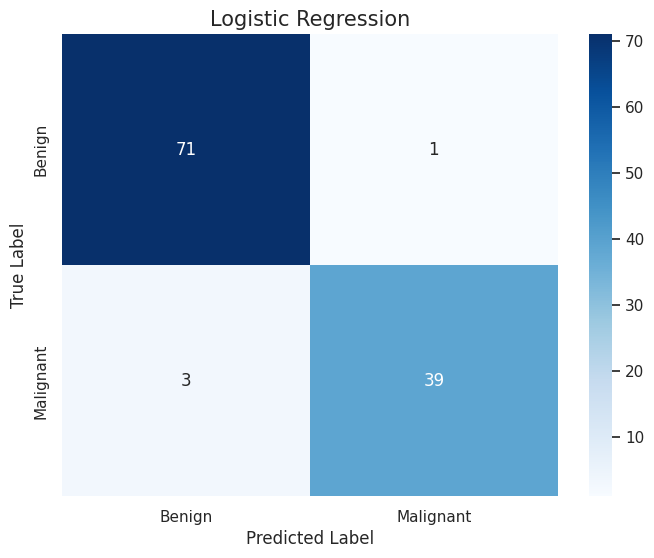

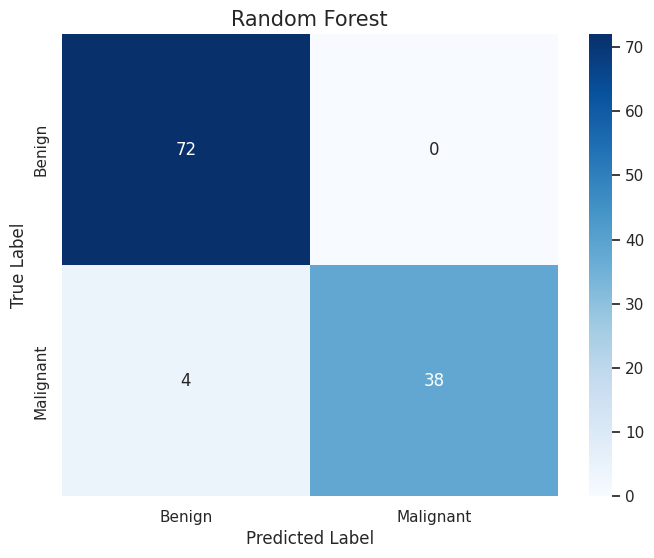

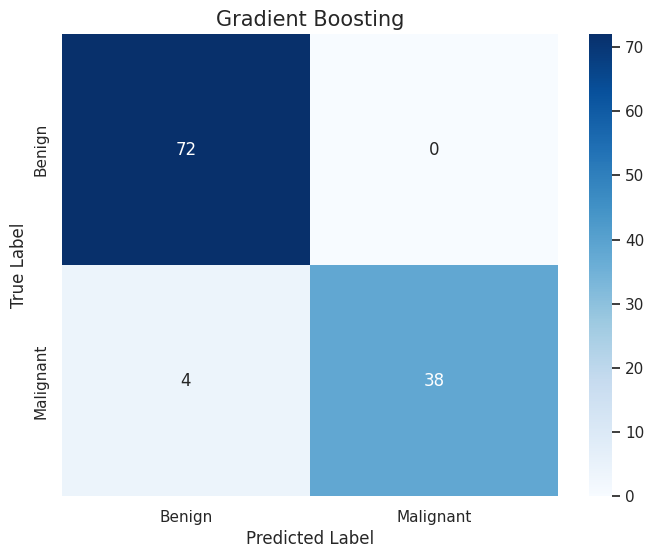

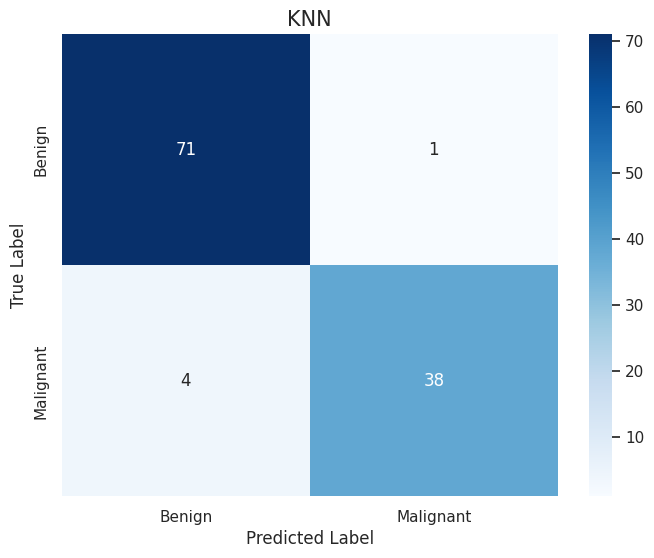

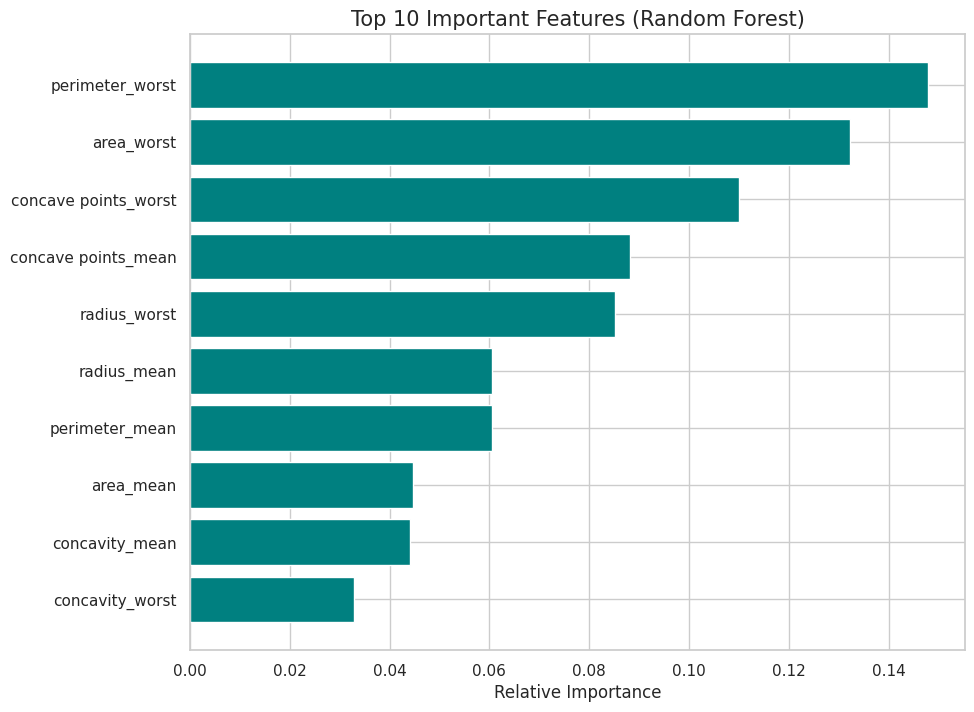

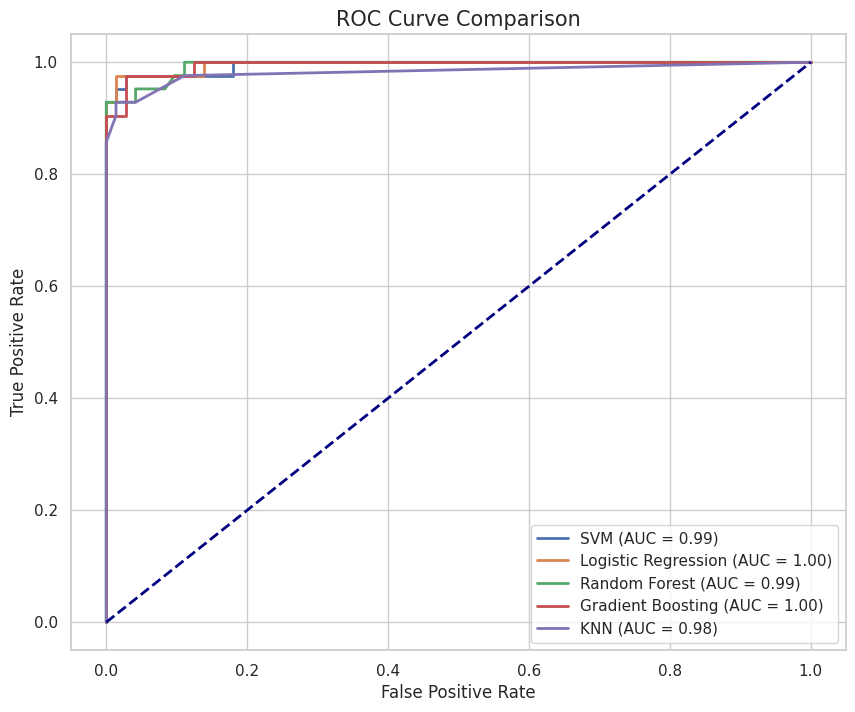

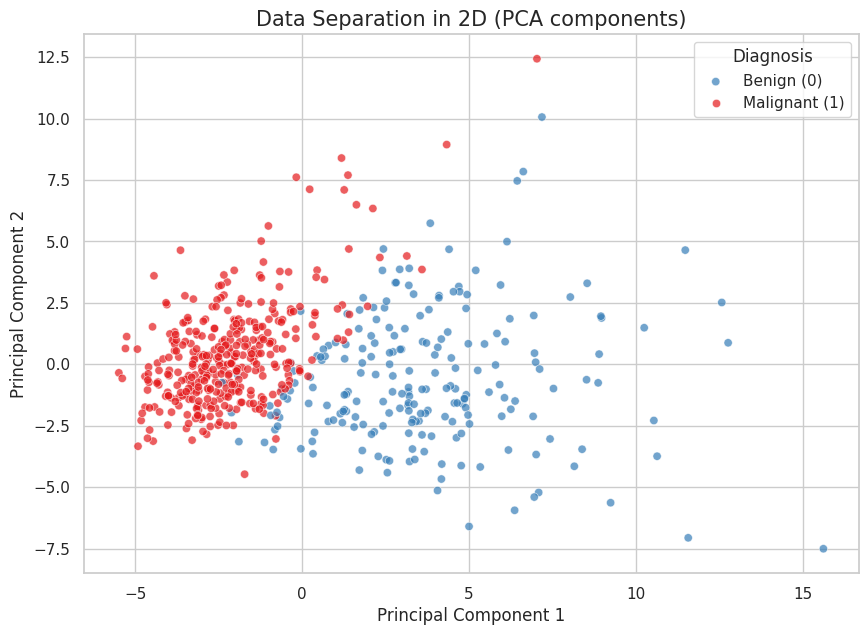

In [ ]:
## VISUALIZATIONS

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Set style
sns.set_theme(style="whitegrid")

# --- 1. Model Accuracy Comparison ---
plt.figure(figsize=(10, 6))
accuracy_scores = {name: accuracy_score(y_test, preds) for name, preds in models.items()}
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="viridis")
plt.title("Model Accuracy Comparison", fontsize=15)
plt.ylabel("Accuracy Score")
plt.ylim(0.8, 1.0) # Zoom in to see differences
plt.show()

# --- 2.1 Confusion Matrix Heatmap (SVM - Best Model) ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("SVM Confusion Matrix", fontsize=15)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- 2.2 Confusion Matrix Heatmap (Logistic Regression) ---
plt.figure(figsize=(8, 6))
lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Logistic Regression", fontsize=15)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- 2.3 Confusion Matrix Heatmap (Random Forest) ---
plt.figure(figsize=(8, 6))
rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Random Forest", fontsize=15)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- 2.4 Confusion Matrix Heatmap (Gradient Boosting)
plt.figure(figsize=(8, 6))
gb = confusion_matrix(y_test, gb_pred)
sns.heatmap(gb, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Gradient Boosting", fontsize=15)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- 2.5 Confusion Matrix Heatmap (KNN)
plt.figure(figsize=(8, 6))
knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("KNN", fontsize=15)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- 3. Feature Importance (Random Forest) ---
# SVM (RBF) doesn't provide easy feature importance, so we use Random Forest
plt.figure(figsize=(10, 8))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features
plt.title("Top 10 Important Features (Random Forest)", fontsize=15)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# --- 4. ROC Curve Comparison ---
plt.figure(figsize=(10, 8))

# SVM Decision Scores
svm_probs = svm_model.decision_function(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, svm_probs)
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc(fpr, tpr):.2f})", lw=2)

# Logistic Regression Probs
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc(fpr, tpr):.2f})", lw=2)

# Random Forest Probs
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc(fpr, tpr):.2f})", lw=2)

#Gradient Boosting
gb_probs = gb_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, gb_probs)
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {auc(fpr, tpr):.2f})", lw=2)

#KNN
knn_probs = knn_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, knn_probs)
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc(fpr, tpr):.2f})", lw=2)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("ROC Curve Comparison", fontsize=15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()



#[Image of ROC curve]


# --- 5. PCA Visualization (2D Class Separation) ---
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.transform(X)) # Scaling full dataset for PCA

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="Set1", alpha=0.7)
plt.title("Data Separation in 2D (PCA components)", fontsize=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Diagnosis', labels=['Benign (0)', 'Malignant (1)'])
plt.show()